# 使用 Monocle 2 进行轨迹推断

本教程使用 GEO `GSE70245` 公开处理后矩阵展示 Olsson 造血分化的 Monocle 2 风格轨迹分析流程。流程包括 DDRTree 重建、分支伪时间流图、动态基因趋势、动态热图和 BEAM 分析，用于从不同层次理解同一条造血轨迹。

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import omicverse as ov
from omicverse.single import Monocle

ov.plot_set(font_path='Arial')
np.random.seed(42)

%reload_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 方法背景

Monocle 官方文档把轨迹推断描述为一个 ordering 问题：先找到能刻画生物学进展的基因，再把细胞投影到低维空间，最后学习一条可分支的 principal graph，从而给每个细胞同时分配 **pseudotime** 和离散的 **State**。在 Monocle 2 里，这套几何通过 reversed graph embedding (RGE) 学出来，实际接口通常表现为 `DDRTree`。

参考资料：
- [Monocle 2 官方文档](https://cole-trapnell-lab.github.io/monocle-release/docs/)
- [Monocle 官方教程集合](https://cole-trapnell-lab.github.io/monocle-release/tutorials/)
- [Monocle 2 RGE 方法论文](https://cole-trapnell-lab.github.io/pdfs/papers/qiu-monocle2.pdf)

Olsson 教程之所以经典，就是因为它展示了 Monocle 2 如何在一个真正具有多个分支点的造血系统中恢复分化主干和命运分叉。


## 数据来源

本教程使用 GEO `GSE70245` 中公开处理后的 Olsson 单细胞矩阵。补充矩阵以 `log2(TPM + 1)` 的 RSEM 表达值提供，配套元数据用于标注样本组和细胞亚型。

## 下载官方 GEO 处理后表达矩阵

Olsson 的 GEO SuperSeries 把单细胞数据拆成了多个子系列。每个子系列都提供了一个处理后的表达表，GEO 元数据里明确写明这些值是 `log2(TPM + 1)` 的 RSEM 表达量。

下面我们直接从 GEO 下载这些单细胞表，并缓存在本地。


In [2]:
DATA_DIR = Path('data/olsson_geo')
RAW_DIR = DATA_DIR / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)

GEO_FILES = [
    {
        'acc': 'GSE70236',
        'filename': 'GSE70236_Cmp.txt.gz',
        'subtype': 'Cmp',
        'genotype': 'WT',
        'url': 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70236/suppl/GSE70236_Cmp.txt.gz',
    },
    {
        'acc': 'GSE70238',
        'filename': 'GSE70238_GG1.txt.gz',
        'subtype': 'GG1',
        'genotype': 'WT',
        'url': 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70238/suppl/GSE70238_GG1.txt.gz',
    },
    {
        'acc': 'GSE70239',
        'filename': 'GSE70239_Gfi1.Null.txt.gz',
        'subtype': 'Gfi1_knockout',
        'genotype': 'KO',
        'url': 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70239/suppl/GSE70239_Gfi1.Null.txt.gz',
    },
    {
        'acc': 'GSE70240',
        'filename': 'GSE70240_Gmp.txt.gz',
        'subtype': 'Gmp',
        'genotype': 'WT',
        'url': 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70240/suppl/GSE70240_Gmp.txt.gz',
    },
    {
        'acc': 'GSE70241',
        'filename': 'GSE70241_IG2.txt.gz',
        'subtype': 'IG2',
        'genotype': 'WT',
        'url': 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70241/suppl/GSE70241_IG2.txt.gz',
    },
    {
        'acc': 'GSE70242',
        'filename': 'GSE70242_Irf8.Null.txt.gz',
        'subtype': 'Irf8_knockout',
        'genotype': 'KO',
        'url': 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70242/suppl/GSE70242_Irf8.Null.txt.gz',
    },
    {
        'acc': 'GSE70243',
        'filename': 'GSE70243_LK.CD34+.txt.gz',
        'subtype': 'LK',
        'genotype': 'WT',
        'url': 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70243/suppl/GSE70243_LK.CD34%2B.txt.gz',
    },
    {
        'acc': 'GSE70244',
        'filename': 'GSE70244_Lsk.txt.gz',
        'subtype': 'Lsk',
        'genotype': 'WT',
        'url': 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70244/suppl/GSE70244_Lsk.txt.gz',
    },
]

for item in GEO_FILES:
    target = RAW_DIR / item['filename']
    if not target.exists():
        print(f"Downloading {item['acc']} -> {target.name}")
        urlretrieve(item['url'], target)
    else:
        print(f"Using cached file: {target.name}")

Using cached file: GSE70236_Cmp.txt.gz
Using cached file: GSE70238_GG1.txt.gz
Using cached file: GSE70239_Gfi1.Null.txt.gz
Using cached file: GSE70240_Gmp.txt.gz
Using cached file: GSE70241_IG2.txt.gz
Using cached file: GSE70242_Irf8.Null.txt.gz
Using cached file: GSE70243_LK.CD34+.txt.gz
Using cached file: GSE70244_Lsk.txt.gz


## 合并 GEO 子系列，生成分析表

为了让后面的分析步骤更直接，我们把下载下来的 GEO 文件整理成：

- 一个表达矩阵
- 一个元数据表

同时也把每个细胞是否属于 WT 或 KO 记录下来。

In [3]:
MERGED_EXPR = DATA_DIR / 'olsson_geo_log2_tpm_613cells.tsv.gz'
MERGED_META = DATA_DIR / 'olsson_geo_metadata_613cells.csv'

def read_geo_matrix(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, sep='	', index_col=0, compression='gzip')


if not MERGED_EXPR.exists() or not MERGED_META.exists():
    matrices = []
    metadata_rows = []
    for item in GEO_FILES:
        df = read_geo_matrix(RAW_DIR / item['filename'])
        matrices.append(df)
        metadata_rows.append(
            pd.DataFrame(
                {
                    'cell_id': df.columns,
                    'subtype': item['subtype'],
                    'genotype': item['genotype'],
                    'geo_accession': item['acc'],
                    'value_type': 'log2(TPM+1) RSEM',
                }
            )
        )

    merged_expr = pd.concat(matrices, axis=1)
    merged_meta = pd.concat(metadata_rows, axis=0, ignore_index=True)
    merged_expr.to_csv(MERGED_EXPR, sep='	', compression='gzip')
    merged_meta.to_csv(MERGED_META, index=False)
else:
    merged_expr = pd.read_csv(MERGED_EXPR, sep='	', index_col=0, compression='gzip')
    merged_meta = pd.read_csv(MERGED_META)

print(f'Merged matrix: {merged_expr.shape[0]} genes x {merged_expr.shape[1]} cells')
merged_meta.head()

Merged matrix: 23955 genes x 613 cells


  cell_id subtype genotype geo_accession        value_type
0   Cmp.1     Cmp       WT      GSE70236  log2(TPM+1) RSEM
1   Cmp.2     Cmp       WT      GSE70236  log2(TPM+1) RSEM
2   Cmp.3     Cmp       WT      GSE70236  log2(TPM+1) RSEM
3   Cmp.4     Cmp       WT      GSE70236  log2(TPM+1) RSEM
4   Cmp.5     Cmp       WT      GSE70236  log2(TPM+1) RSEM

## 构建 AnnData 对象

表达矩阵使用 GEO 提供的 `log2(TPM + 1)` 数值，元数据用于后续分组、轨迹和可视化。

In [4]:
merged_expr = pd.read_csv(MERGED_EXPR, sep='	', index_col=0, compression='gzip')
merged_meta = pd.read_csv(MERGED_META).set_index('cell_id')

adata = ad.AnnData(X=merged_expr.T.astype(np.float32))
adata.obs = merged_meta.loc[merged_expr.columns].copy()
adata.var['gene_short_name'] = merged_expr.index.astype(str)
adata.var_names = merged_expr.index.astype(str)
adata

AnnData object with n_obs × n_vars = 613 × 23955
    obs: 'subtype', 'genotype', 'geo_accession', 'value_type'
    var: 'gene_short_name'

## 聚焦 WT 造血分化主干

下面将 WT 条件下的 `Lsk`、`Cmp`、`Gmp` 和 `LK` 作为主要分析对象。

In [5]:
wt_types = ['Lsk', 'Cmp', 'Gmp', 'LK']
adata_wt = adata[adata.obs['subtype'].isin(wt_types)].copy()
print(f'WT cells: {adata_wt.n_obs}')
adata_wt.obs['subtype'].value_counts()

WT cells: 394


subtype
Gmp    136
Cmp     96
Lsk     96
LK      66
Name: count, dtype: int64

## Monocle 预处理与 ordering gene 选择

这里使用 OmicVerse 的 ordering-gene 选择步骤，先找出能够刻画造血进展的一组高信息量基因，再据此学习轨迹几何。

Ordering genes: 1000


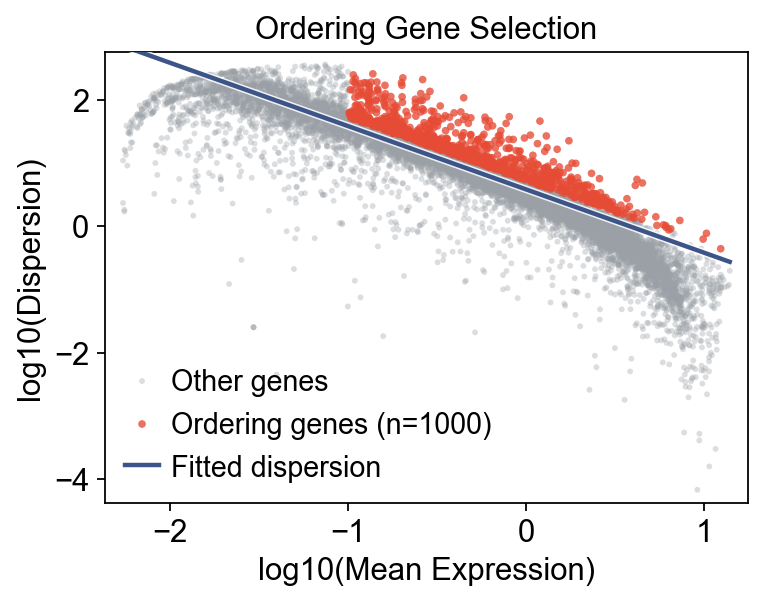

In [6]:
mono = Monocle(adata_wt)
mono.preprocess()
mono.select_ordering_genes(max_genes=1000)
print(f"Ordering genes: {mono.adata.var['use_for_ordering'].sum()}")

mono.plot_ordering_genes(figsize=(5, 4))
plt.show()

## 学习 DDRTree 轨迹并计算伪时间

这里保持 Monocle 2 风格设置：先在 4 维空间中学习轨迹，再把根节点放在 `Lsk` 群体上。


In [7]:
mono.reduce_dimension(max_components=4, verbose=False)
mono.order_cells(root_by_column='subtype', root_by_value='Lsk')
print(mono)

[monocle2_py] Using fast DDRTree (≈3× speed-up, pseudotime correlation with R ≥ 0.99). Pass method='exact' for bitwise R Monocle 2 parity.
Monocle(394 cells × 23955 genes)
  preprocessed: ✓
  ordering genes: 1000
  reduced: DDRTree
  ordered: pseudotime [0.00, 11.99], 12 states


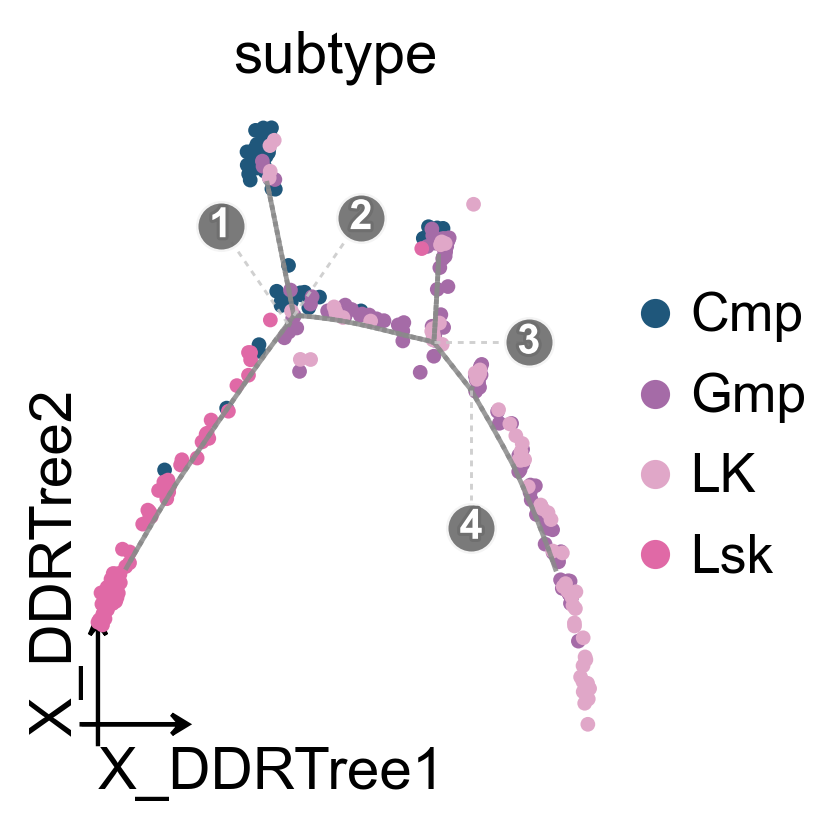

In [12]:
ov.pl.trajectory(
    mono.adata,
    method='monocle',
    basis='X_DDRTree',
    color='subtype',
    figsize=(3.5,3),
)
ov.plt.show()

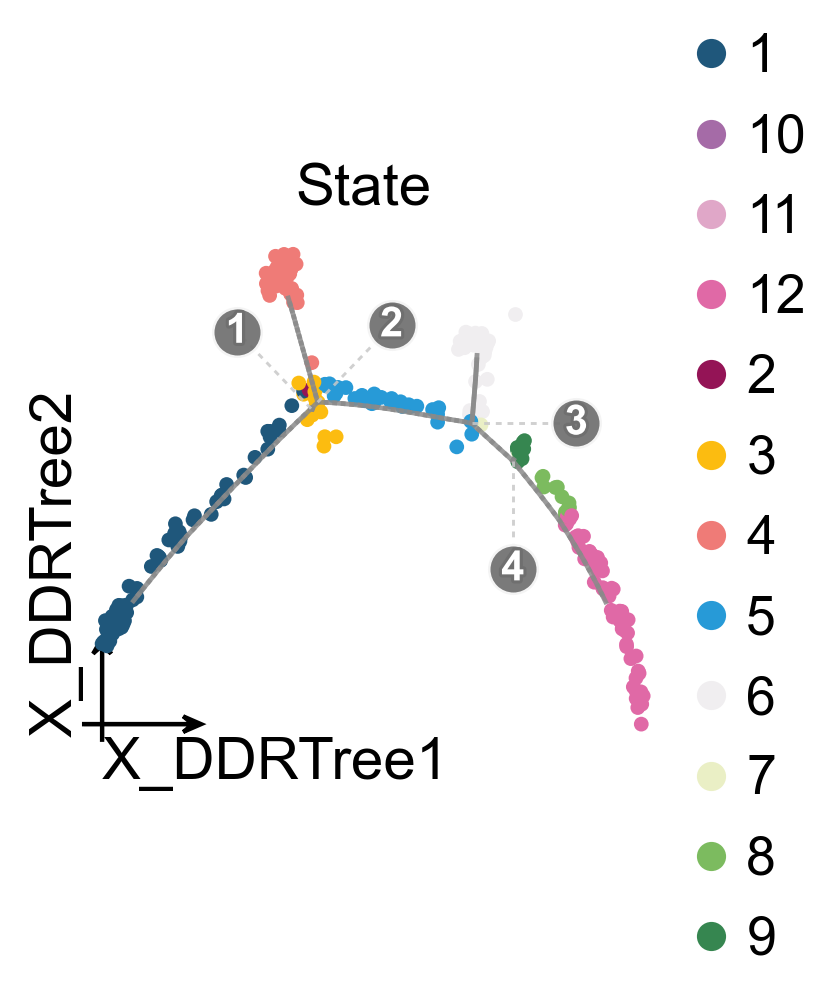

In [13]:
ov.pl.trajectory(
    mono.adata,
    method='monocle',
    basis='X_DDRTree',
    color='State',
    figsize=(3.5,3),
)
ov.plt.show()

## OV 轨迹图和投影视图

同一个 Monocle 结果也可以通过新的 `trajectory_graph` 和 `trajectory_projection` 入口展示，与其他轨迹教程使用同一套可视化 API。

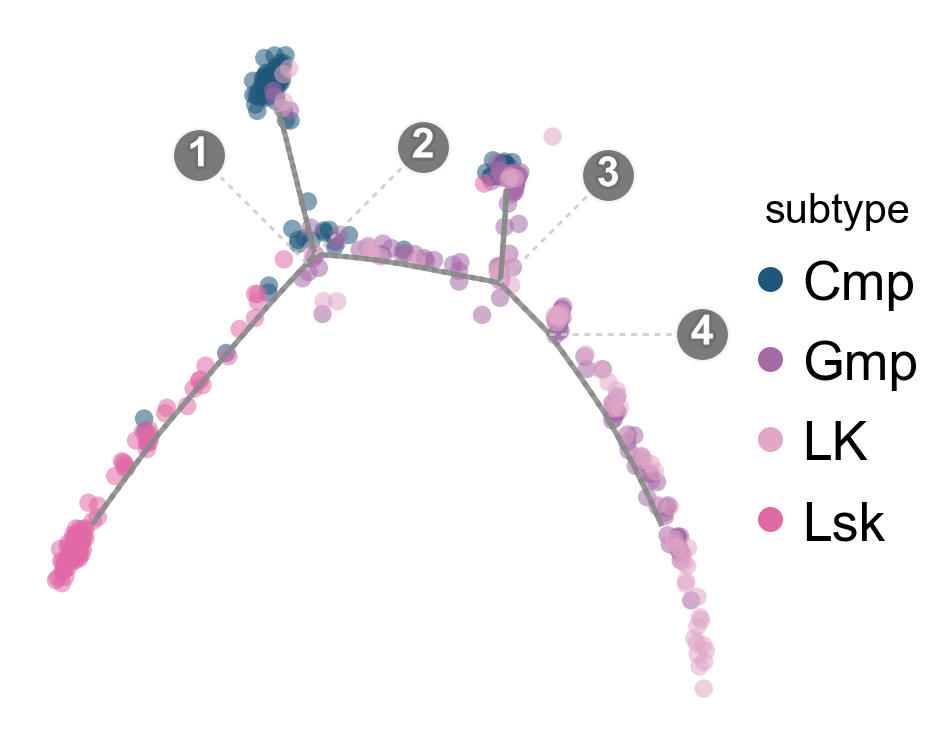

In [15]:
fig, ax = ov.pl.trajectory_graph(
    mono.adata,
    method='monocle',
    basis='X_DDRTree',
    color='subtype',
    figsize=(3,3),
)
ov.plt.show()

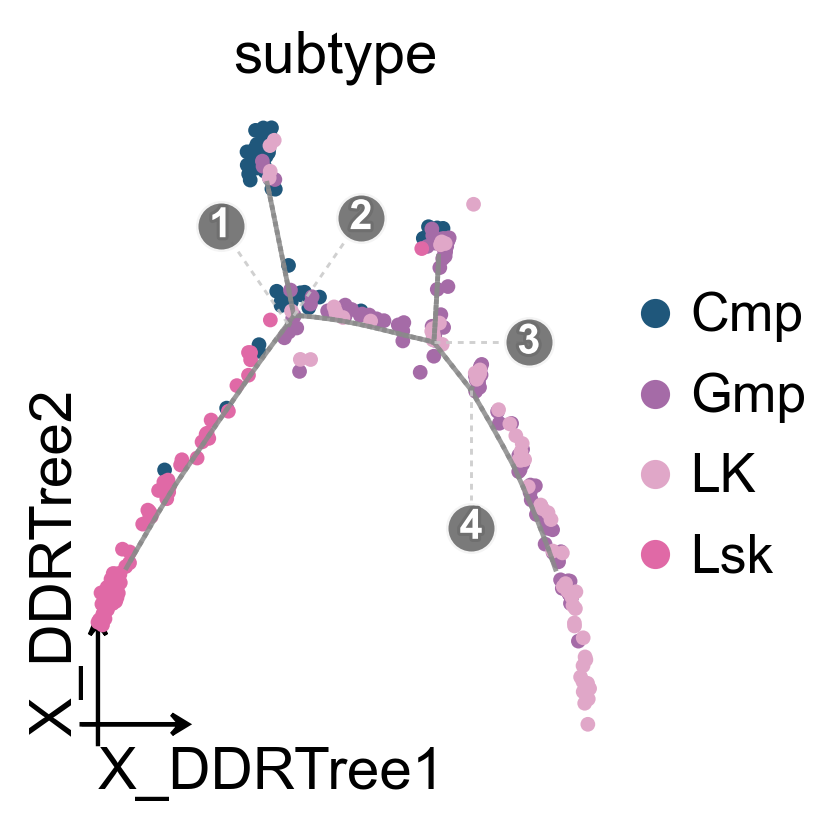

In [16]:
fig, ax = ov.pl.trajectory_projection(
    mono.adata,
    method='monocle',
    basis='X_DDRTree',
    color='subtype',
    figsize=(3.5,3),
)
ov.plt.show()

## 在 DDRTree embedding 上叠加轨迹

`ov.pl.trajectory_overlay` 可以把灰色 principal graph 和分支点编号叠加到已有的 OmicVerse embedding 坐标轴上，使细胞颜色和图例与 `ov.pl.embedding` 保持一致。

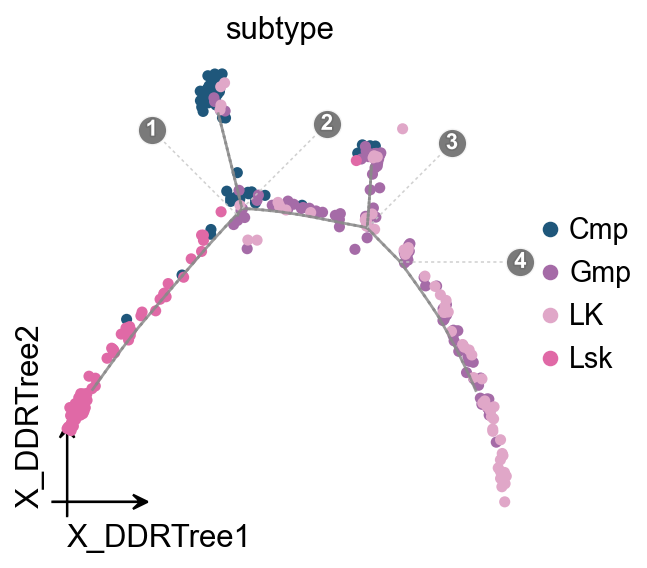

In [19]:
fig, ax = ov.plt.subplots(figsize=(4, 4))
ov.pl.embedding(
    mono.adata,
    basis='X_DDRTree',
    color='subtype',
    ax=ax,
    show=False,
    size=100,
)
ov.pl.trajectory_overlay(mono.adata, ax=ax, method='monocle')
ov.plt.show()

## 复杂树状布局

当我们更关心沿伪时间的整体推进关系时，树状布局往往比默认的低维散点图更容易阅读。这里它能更清楚地把早期 progenitor 主干和后续分支结构分开。


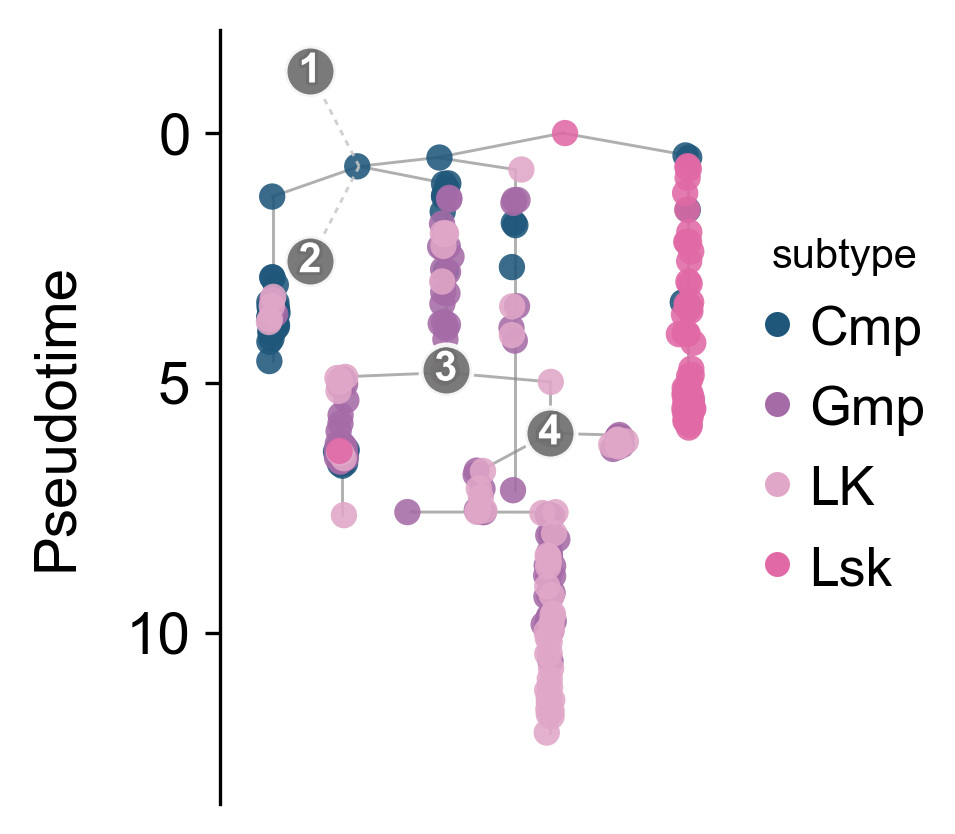

In [21]:
ov.pl.trajectory_tree(
    mono.adata,
    method='monocle',
    color='subtype',
    figsize=(4,3),
)
ov.plt.show()

## State 与 subtype 的对应关系

用一个简单的列联热图来检查 Monocle 状态是否大致沿着 `Lsk -> Cmp/LK -> Gmp` 的方向展开。


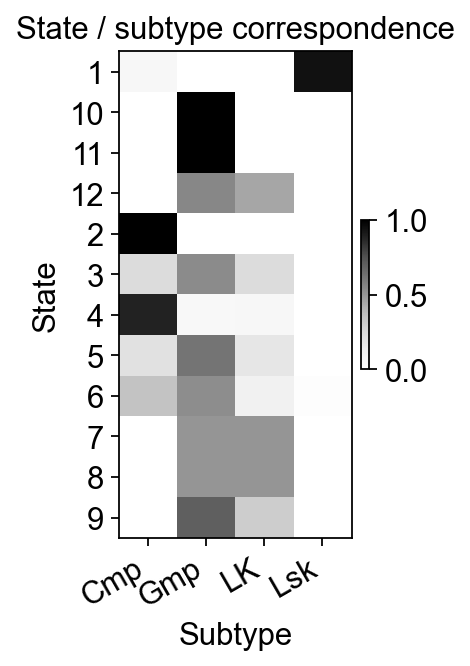

In [14]:
state_subtype = pd.crosstab(mono.adata.obs['State'], mono.adata.obs['subtype'])
state_subtype_norm = state_subtype.div(state_subtype.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(2, 4))
im = ax.imshow(state_subtype_norm.values, aspect='auto', cmap='Greys')
ax.set_xticks(range(state_subtype_norm.shape[1]))
ax.set_xticklabels(state_subtype_norm.columns, rotation=30, ha='right')
ax.set_yticks(range(state_subtype_norm.shape[0]))
ax.set_yticklabels(state_subtype_norm.index)
ax.set_xlabel('Subtype')
ax.set_ylabel('State')
ax.set_title('State / subtype correspondence')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
plt.show()

## 面向分支的伪时间流图

`ov.pl.branch_streamplot` 可以把 Monocle 伪时间和各 subtype 的密度变化整理成一张 river-style 图。相比 2D Monocle 布局，这种图更适合直接观察早期造血主干在哪个位置收缩，以及后续 subtype 分支又是在什么位置逐渐展开。

在这类图里，ribbon 的宽度反映了对应 subtype 在相应伪时间位置上的相对丰度。


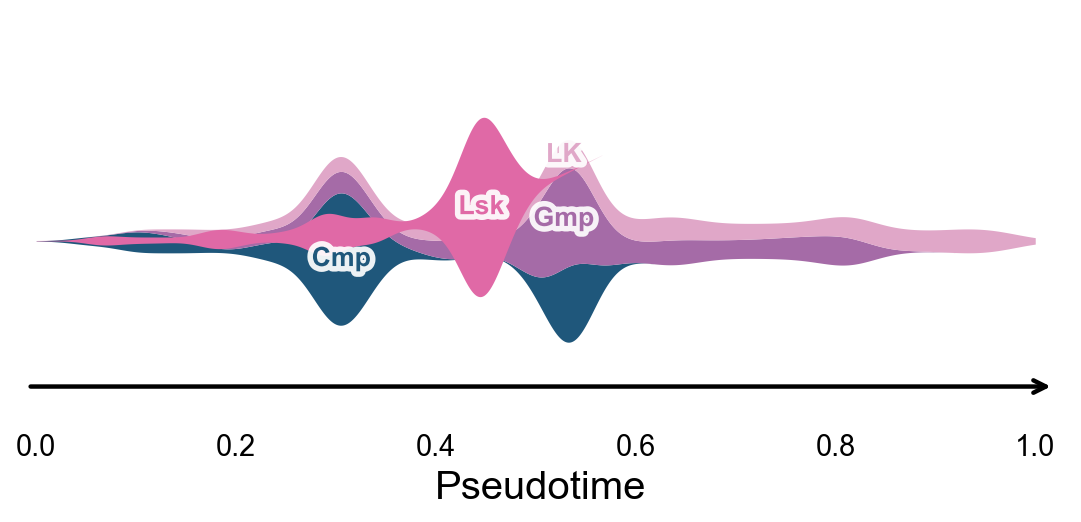

In [15]:
fig, ax = ov.pl.branch_streamplot(
    mono.adata,
    group_key='subtype',
    pseudotime_key='Pseudotime',
    show=False,
)
plt.show()

## 沿伪时间变化的基因

在进一步关注分支特异性之前，先看哪些基因在整个造血进展过程中变化最明显，会更容易把握 Monocle 当前学到的主轴到底对应哪些转录程序。



🔍 Dynamic heatmap:
   Candidate features: 40
   Pseudotime: Pseudotime
   Cell annotation: State
   use_fitted=True | cell_bins=200 | cmap=RdBu_r



✅ Dynamic heatmap completed!
   ✓ Matrix shape: 40 features × 122 columns


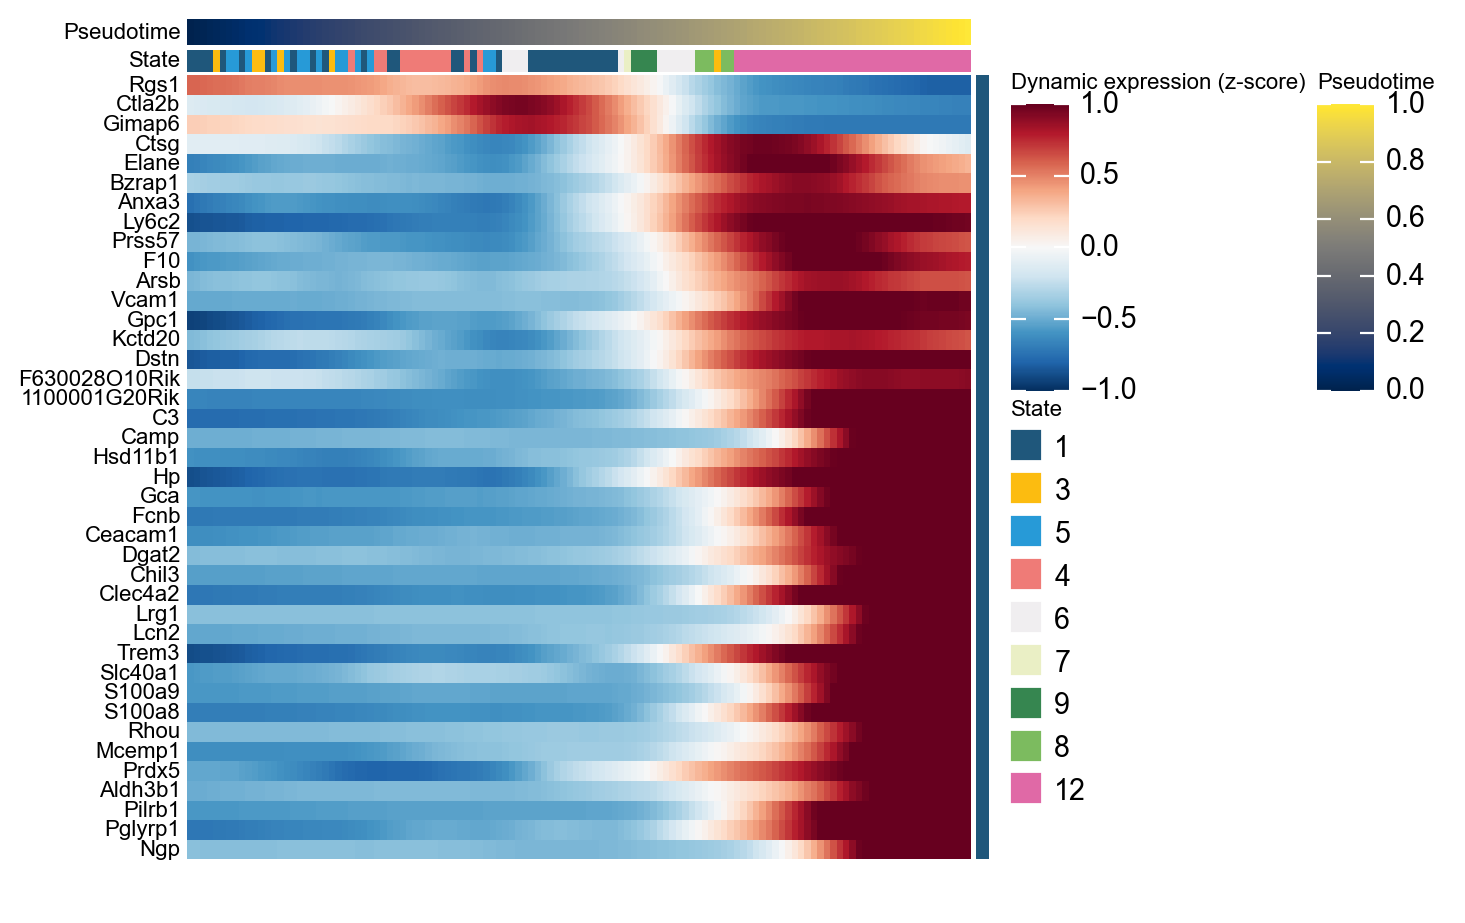

In [17]:
ordering_genes = mono.adata.var_names[mono.adata.var['use_for_ordering']].tolist()
mono_ord = Monocle(mono.adata[:, ordering_genes].copy())

de = mono_ord.differential_gene_test(cores=-1)
sig = de[(de['qval'] < 0.01) & (de['status'] == 'OK')]

top40 = sig.sort_values('pval').head(40).index.tolist()

g = ov.pl.dynamic_heatmap(
    mono.adata,
    pseudotime='Pseudotime',
    var_names=top40,
    cell_annotation='State',
    use_cell_columns=False,
    use_fitted=True,
    cell_bins=200,
    figsize=(7, 7),
    show_row_names=True,
    standard_scale='var',
    cmap='RdBu_r',
    order_by='peak',
    show=False,
)

## 沿伪时间查看代表性 marker gene

经典造血 marker 能提供一个很直接的生物学 sanity check：如果当前 pseudotime 合理，早期 progenitor marker 和后期分支 marker 应该会按可解释的顺序出现。


### Single-line global trends

这张图为每个 marker 只拟合一条全局趋势线，同时用 Monocle 推断的 `State` 给原始散点着色。它适合判断表达变化是整体伪时间趋势，还是主要由特定状态的细胞分布驱动。



🔍 Dynamic feature analysis:
   Views: 1 | Features: 6
   Pseudotime: Pseudotime
   Stored raw obs keys: ['State']
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/6 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 6/6
   ✓ Fitted rows: 1200
   ✓ Raw observations stored: 2364

🔍 Dynamic trend plotting:
   Features: 6 | Groups: 1
   compare_features=False | compare_groups=False


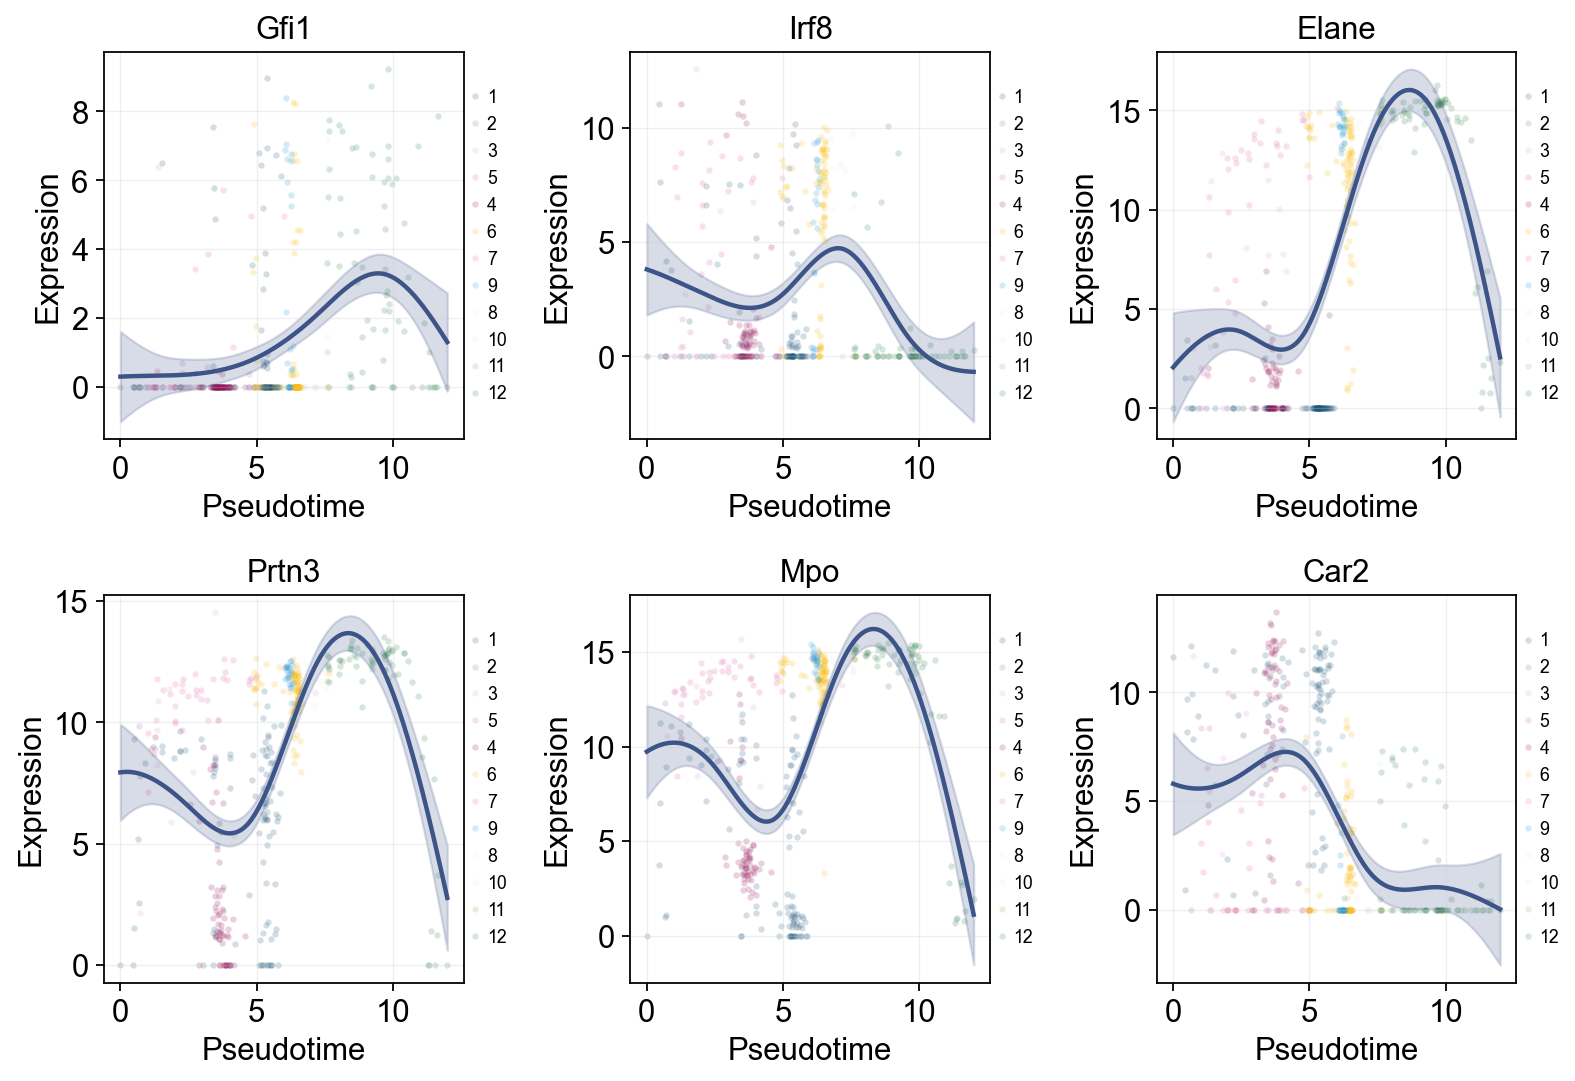

✅ Dynamic trend plotting completed!


In [18]:
import pandas as pd

marker_genes = [g for g in ['Gfi1', 'Irf8', 'Elane', 'Prtn3', 'Mpo', 'Car2'] if g in mono.adata.var_names]

res = ov.single.dynamic_features(
    mono.adata,
    genes=marker_genes,
    pseudotime='Pseudotime',
    store_raw=True,
    raw_obs_keys=['State'],
)

ov.pl.dynamic_trends(
    res,
    genes=marker_genes,
    add_point=True,
    point_color_by='State',
    figsize=(4, 3.5),
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()

## 使用 `dynamic_features` 与 `dynamic_trends` 查看 marker 动态

`ov.single.dynamic_features` 可以沿 Monocle 伪时间拟合 GAM 趋势。这里我们先用全局模式画出整个造血过程中的 marker 曲线，并用 subtype 给原始散点着色；随后再单独拟合下游两条主要分支，展示分支相关的表达变化。

In [19]:
marker_genes = [g for g in ['Gfi1', 'Irf8', 'Elane', 'Prtn3', 'Mpo', 'Car2'] if g in mono.adata.var_names]

olsson_global_dyn = ov.single.dynamic_features(
    mono.adata,
    genes=marker_genes,
    pseudotime='Pseudotime',
    use_raw=False,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
    raw_obs_keys=['subtype', 'State'],
)

trend_genes = [g for g in ['Gfi1', 'Irf8', 'Elane', 'Car2'] if g in marker_genes]


🔍 Dynamic feature analysis:
   Views: 1 | Features: 6
   Pseudotime: Pseudotime
   Stored raw obs keys: ['subtype', 'State']
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/6 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 6/6
   ✓ Fitted rows: 1200
   ✓ Raw observations stored: 2364



🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=True | compare_groups=False


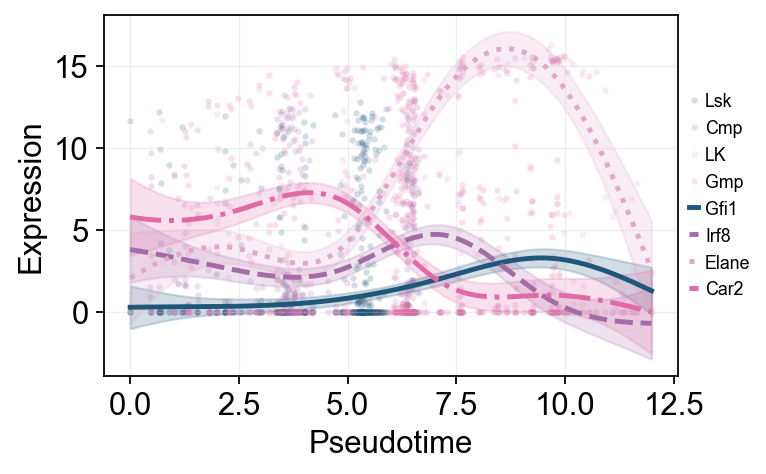

✅ Dynamic trend plotting completed!


In [20]:
ov.pl.dynamic_trends(
    olsson_global_dyn,
    genes=trend_genes,
    compare_features=True,
    add_point=True,
    point_color_by='subtype',
    line_style_by='features',
    figsize=(6, 3.2),
    linewidth=2.2,
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()

In [21]:
branch_subtypes = ['Gmp', 'LK']
branch_split_mask = mono.adata.obs['subtype'].astype(str).isin(['Cmp'])

olsson_branch_dyn = ov.single.dynamic_features(
    mono.adata,
    genes=trend_genes,
    pseudotime='Pseudotime',
    groupby='subtype',
    groups=branch_subtypes,
    use_raw=False,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
)
branch_split_time = float(np.nanmedian(mono.adata.obs.loc[branch_split_mask, 'Pseudotime'])) if branch_split_mask.any() else float(np.nanmedian(mono.adata.obs['Pseudotime']))


🔍 Dynamic feature analysis:
   Views: 2 | Features: 4
   Pseudotime: Pseudotime
   Grouping: subtype
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/8 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 8/8
   ✓ Fitted rows: 1600
   ✓ Raw observations stored: 808



🔍 Dynamic trend plotting:
   Features: 4 | Groups: 2
   compare_features=False | compare_groups=True


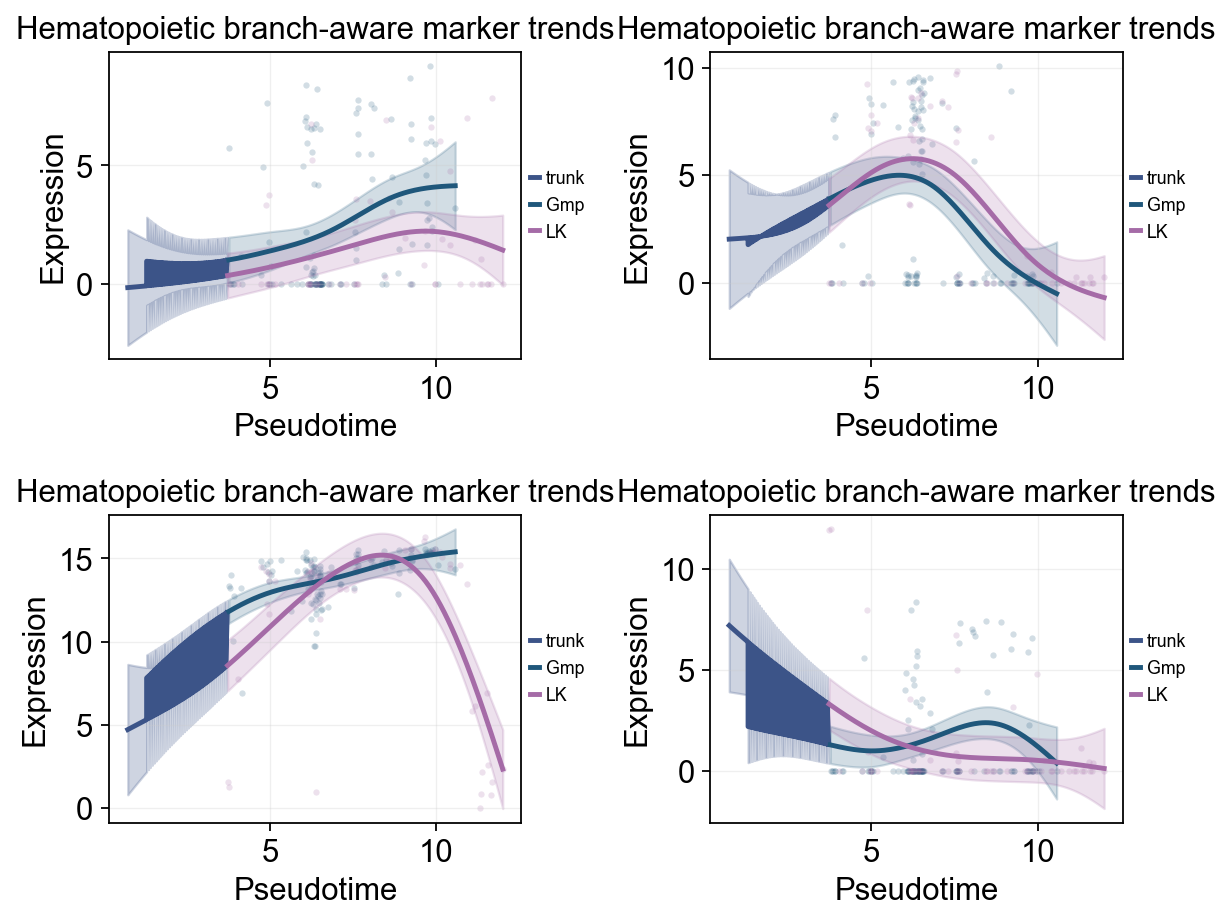

✅ Dynamic trend plotting completed!


In [22]:
ov.pl.dynamic_trends(
    olsson_branch_dyn,
    genes=trend_genes,
    compare_groups=True,
    split_time=branch_split_time,
    shared_trunk=True,
    add_point=True,
    point_color_by='group',
    figsize=(4.6, 3),
    linewidth=2.2,
    ncols=2,
    legend_loc='right margin',
    legend_fontsize=8,
    title='Hematopoietic branch-aware marker trends',
)
plt.show()

## 使用 `dynamic_heatmap` 概括造血 program

`ov.pl.dynamic_heatmap` 能把多组 marker program 压缩成一张按伪时间排序的热图，非常适合从整体上比较不同程序的启动顺序。

读图时可以重点看哪些 program 在前期就较强，哪些是在后期沿某个分支逐渐升高。前者通常对应 progenitor 特征，后者则更接近下游命运承诺。



🔍 Dynamic heatmap:
   Candidate features: 6
   Pseudotime: Pseudotime
   Cell annotation: subtype
   use_fitted=True | cell_bins=140 | cmap=RdBu_r

✅ Dynamic heatmap completed!
   ✓ Matrix shape: 6 features × 97 columns


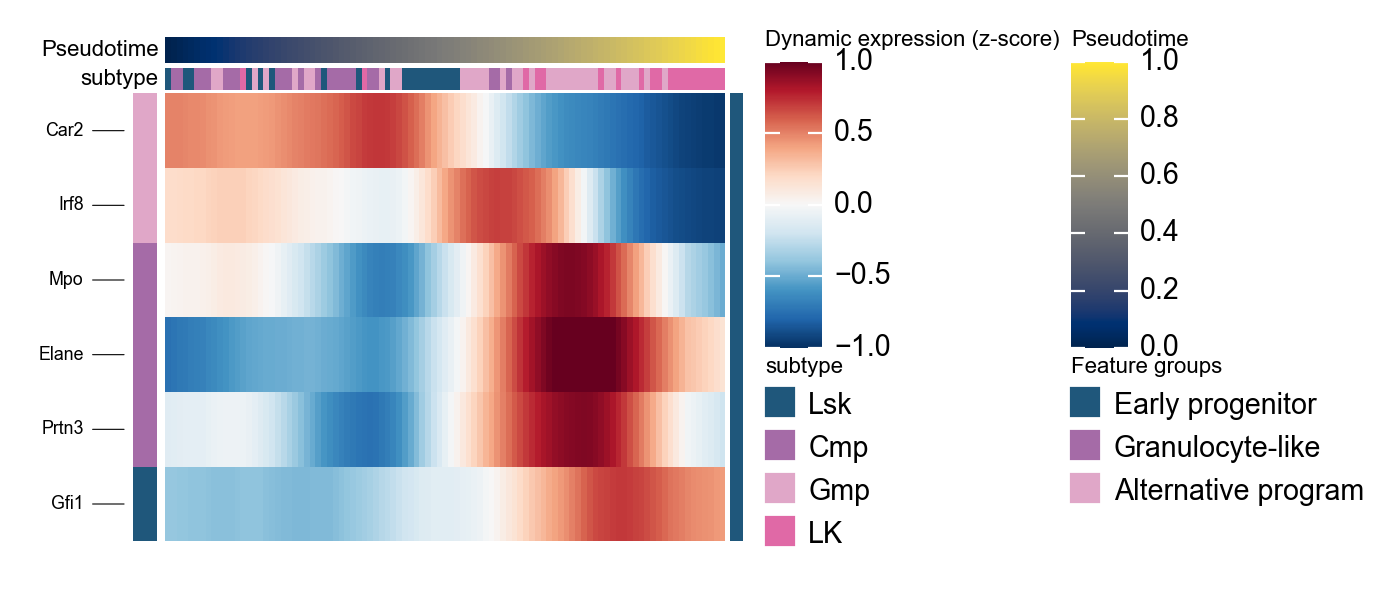

In [23]:
olsson_marker = {
    'Early progenitor': [g for g in ['Gfi1'] if g in mono.adata.var_names],
    'Granulocyte-like': [g for g in ['Elane', 'Prtn3', 'Mpo'] if g in mono.adata.var_names],
    'Alternative program': [g for g in ['Irf8', 'Car2'] if g in mono.adata.var_names],
}
olsson_marker = {k: v for k, v in olsson_marker.items() if v}

g = ov.pl.dynamic_heatmap(
    mono.adata,
    var_names=olsson_marker,
    pseudotime='Pseudotime',
    use_raw=False,
    use_cell_columns=False,
    cell_annotation='subtype',
    cell_bins=140,
    smooth_window=13,
    fitted_window=25,
    figsize=(5, 4),
    standard_scale='var',
    cmap='RdBu_r',
    use_fitted=True,
    border=False,
    show=False,
)

## 使用 BEAM 寻找分支相关基因

BEAM 用于排序主分支点之后表达轨迹发生分化的基因。这里直接把显著性最高的一组基因交给 `dynamic_trends`，用于比较下游 subtype 的表达程序。


BEAM 显著基因数: 141/1000


         pval  qval
uid                
Gm6289    0.0   0.0
Gm20753   0.0   0.0
Gm20594   0.0   0.0
Gm20172   0.0   0.0
Gm15880   0.0   0.0
Satb2     0.0   0.0
Gm10408   0.0   0.0
Gcm1      0.0   0.0
Gal3st3   0.0   0.0
Rn45s     0.0   0.0


🔍 Dynamic feature analysis:
   Views: 2 | Features: 4
   Pseudotime: Pseudotime
   Grouping: subtype
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/8 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 7/8
   ✓ Fitted rows: 1400
   ✓ Raw observations stored: 742

🔍 Dynamic trend plotting:
   Features: 4 | Groups: 2
   compare_features=False | compare_groups=True


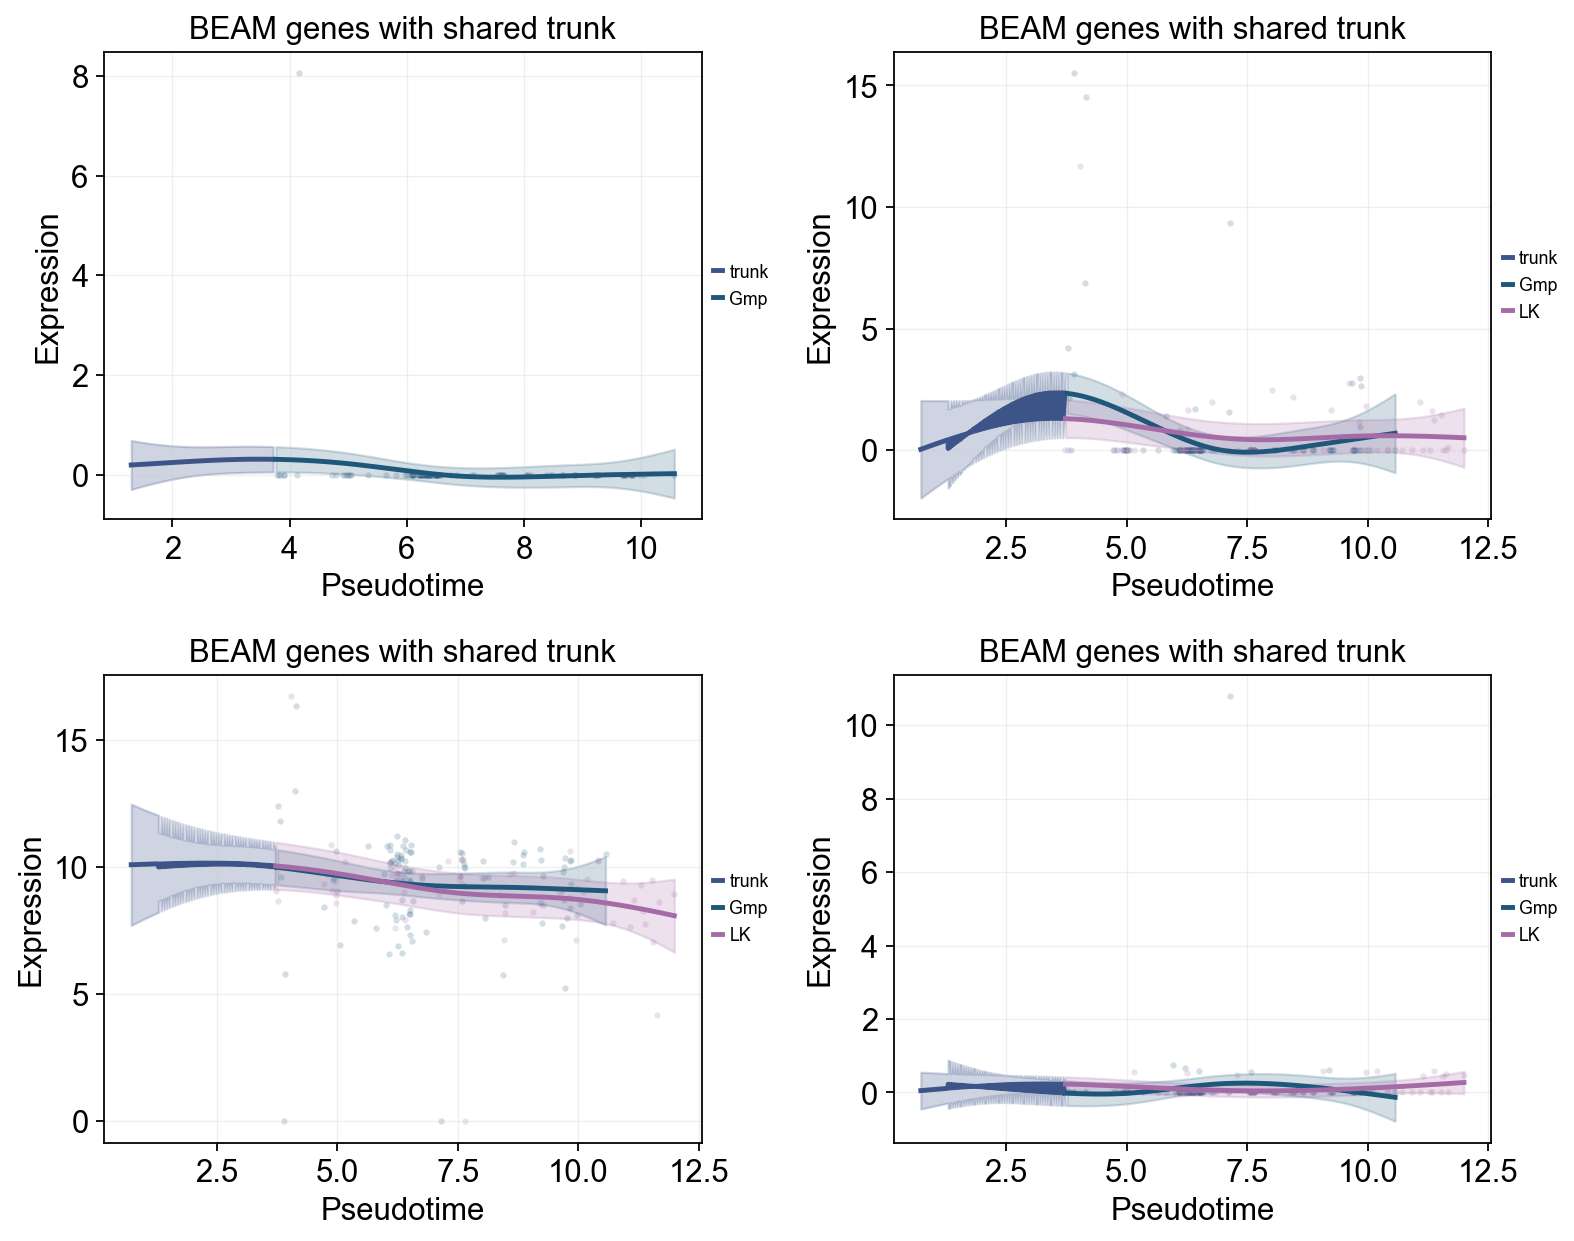

✅ Dynamic trend plotting completed!


In [24]:
beam = mono_ord.BEAM(branch_point=1, cores=-1)
sig_beam = beam[beam['qval'] < 0.01].sort_values('qval')
print(f'BEAM 显著基因数: {len(sig_beam)}/{len(beam)}')
display(sig_beam.head(10)[['pval', 'qval']])

top_branch_genes = sig_beam.head(4).index.tolist()
beam_branch_subtypes = ['Gmp', 'LK']

beam_dyn = ov.single.dynamic_features(
    mono.adata,
    genes=top_branch_genes,
    pseudotime='Pseudotime',
    groupby='subtype',
    groups=beam_branch_subtypes,
    use_raw=False,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
)
beam_split_mask = mono.adata.obs['subtype'].astype(str).isin(['Cmp'])
beam_split_time = float(np.nanmedian(mono.adata.obs.loc[beam_split_mask, 'Pseudotime'])) if beam_split_mask.any() else float(np.nanmedian(mono.adata.obs['Pseudotime']))

ov.pl.dynamic_trends(
    beam_dyn,
    genes=top_branch_genes,
    compare_groups=True,
    split_time=beam_split_time,
    shared_trunk=True,
    add_point=True,
    point_color_by='group',
    figsize=(6, 4),
    linewidth=2.2,
    ncols=2,
    legend_loc='right margin',
    legend_fontsize=8,
    title='BEAM genes with shared trunk',
)
plt.show()